## 1 · Imports & Setup

In [1]:
import warnings, textwrap
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ All imports loaded successfully.')

✅ All imports loaded successfully.


## 2 · Data Loading

In [2]:
PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / 'data' / 'processed'

df_raw = pd.read_csv(PROC / 'cleaned_apple_sales_v3.csv')
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Raw dataset: 1,068,918 rows × 35 columns


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2021-01-01,ST-41,P-29,2,iPhone 13 Pro,2021-01-01,999.0,Apple Central World,Bangkok,...,1.0,1009.471395,0,0.000250,1.0,1.222605,2.434251,1,1009.471395,1
1,ZI-218670,2021-01-01,ST-20,P-40,1,AirTag,2021-01-01,29.0,Apple Kaerntner Strasse,Vienna,...,1.0,29.436802,0,-0.000038,1.0,1.089382,1.666149,0,0.000000,1
2,VB-48589,2021-01-01,ST-60,P-41,9,Apple Watch Series 7,2021-01-01,399.0,Apple Antara,Mexico City,...,1.0,415.935057,0,0.000208,1.0,1.202036,7.739726,11,4575.285624,1


## 3 · Preprocessing — Monthly Store-Level Aggregation



In [3]:
# =============================================================================
# CLEANER FORECASTING PIPELINE
# Reduced Overfitting + Safer Features
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# =============================================================================
# 1. LOAD DATA
# =============================================================================

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / 'data' / 'processed'

df_raw = pd.read_csv(PROC / 'cleaned_apple_sales_v3.csv')

print(f'Raw dataset: {df_raw.shape}')

# =============================================================================
# 2. BASIC PREPROCESSING
# =============================================================================

df_raw['sale_date'] = pd.to_datetime(df_raw['sale_date'])

df_raw['year'] = df_raw['sale_date'].dt.year
df_raw['month'] = df_raw['sale_date'].dt.month

# normalize country
if 'country_norm_mapped' not in df_raw.columns:

    df_raw['country_norm_mapped'] = (
        df_raw['country']
        .str.lower()
        .str.strip()
    )

# =============================================================================
# 3. MONTHLY AGGREGATION
# =============================================================================

monthly_aggs = {

    'sales_amount_realistic': 'sum',
    'quantity_realistic': 'sum',

    # average monthly basket price
    'price_realistic': 'mean',

    'store_name': 'first',
    'country_norm_mapped': 'first',

    # % promo transactions
    'promo_flag': 'mean',
}

# economic features
for ecol in [
    'gdp_per_capita',
    'inflation_rate',
    'exchange_rate',
    'internet_usage_pct'
]:

    if ecol in df_raw.columns:
        monthly_aggs[ecol] = 'first'

# groupby
df_monthly = (

    df_raw
    .groupby(['store_id', 'year', 'month'])
    .agg(monthly_aggs)
    .reset_index()
)

# =============================================================================
# 4. EXTRA MONTHLY FEATURES
# =============================================================================

# number of transactions
df_monthly['num_transactions'] = (

    df_raw
    .groupby(['store_id', 'year', 'month'])
    .size()
    .values
)

# unique products
df_monthly['num_unique_products'] = (

    df_raw
    .groupby(['store_id', 'year', 'month'])['product_id']
    .nunique()
    .values
)

# unique categories
if 'category_id' in df_raw.columns:

    df_monthly['num_categories'] = (

        df_raw
        .groupby(['store_id', 'year', 'month'])['category_id']
        .nunique()
        .values
    )

# =============================================================================
# 5. DATE COLUMN
# =============================================================================

df_monthly['date'] = pd.to_datetime(
    df_monthly[['year', 'month']].assign(day=1)
)

df_monthly.sort_values(
    ['store_id', 'date'],
    inplace=True
)

df_monthly.reset_index(
    drop=True,
    inplace=True
)

print()
print(f'Monthly dataset: {df_monthly.shape}')

# =============================================================================
# 6. TARGET
# =============================================================================

TARGET = 'sales_amount_realistic'

# =============================================================================
# 7. LAG FEATURES
# =============================================================================

SAFE_LAGS = [1, 2, 3, 6, 12]

for lag in SAFE_LAGS:

    df_monthly[f'sales_lag_{lag}'] = (

        df_monthly
        .groupby('store_id')[TARGET]
        .shift(lag)
    )

# =============================================================================
# 8. ROLLING FEATURES
# =============================================================================

ROLL_WINDOWS = [3, 6]

for w in ROLL_WINDOWS:

    rolled = (

        df_monthly
        .groupby('store_id')[TARGET]
        .shift(1)
        .rolling(w, min_periods=1)
    )

    df_monthly[f'sales_roll_mean_{w}'] = (

        rolled
        .mean()
        .reset_index(0, drop=True)
    )

# =============================================================================
# 9. MOMENTUM FEATURES
# =============================================================================

df_monthly['sales_mom_pct'] = (

    df_monthly
    .groupby('store_id')[TARGET]
    .pct_change()
)

df_monthly['sales_lag1_vs_roll6'] = (

    df_monthly['sales_lag_1'] /
    df_monthly['sales_roll_mean_6'].replace(0, np.nan)
)

# =============================================================================
# 10. CYCLICAL TIME FEATURES
# =============================================================================

df_monthly['month_sin'] = np.sin(
    2 * np.pi * df_monthly['month'] / 12
)

df_monthly['month_cos'] = np.cos(
    2 * np.pi * df_monthly['month'] / 12
)

df_monthly['is_holiday_season'] = (
    df_monthly['month']
    .isin([11, 12])
    .astype(int)
)

df_monthly['is_launch_season'] = (
    df_monthly['month']
    .isin([9, 10])
    .astype(int)
)

# =============================================================================
# 11. ECONOMIC CHANGES
# =============================================================================

for col in [

    'gdp_per_capita',
    'inflation_rate',
    'exchange_rate',
    'internet_usage_pct'
]:

    if col in df_monthly.columns:

        new_col = (

            col
            .replace('_per_capita', '')
            .replace('_rate', '')
            .replace('_pct', '')
            + '_change'
        )

        df_monthly[new_col] = (

            df_monthly
            .groupby('store_id')[col]
            .pct_change()
            .fillna(0)
        )

# =============================================================================
# 12. STORE ENCODING
# =============================================================================

le = LabelEncoder()

df_monthly['store_encoded'] = (

    le.fit_transform(df_monthly['store_id'])
)

# =============================================================================
# 13. CLEAN NaNs
# =============================================================================

df_monthly['row_num'] = (

    df_monthly
    .groupby('store_id')
    .cumcount()
)

# remove first 12 months
df_clean = (

    df_monthly[df_monthly['row_num'] >= 12]
    .copy()
)

df_clean.drop(columns='row_num', inplace=True)

# fill remaining NaNs
numeric_cols = df_clean.select_dtypes(
    include=[np.number]
).columns

df_clean[numeric_cols] = (

    df_clean[numeric_cols]
    .fillna(0)
)

print()
print(f'After cleaning: {df_clean.shape}')

# =============================================================================
# 14. FINAL FEATURES
# =============================================================================

FEATURES = [

    # lag features
    'sales_lag_1',
    'sales_lag_2',
    'sales_lag_3',
    'sales_lag_6',
    'sales_lag_12',

    # rolling means
    'sales_roll_mean_3',
    'sales_roll_mean_6',

    # momentum
    'sales_mom_pct',
    'sales_lag1_vs_roll6',

    # pricing
    'price_realistic',
    'promo_flag',

    # seasonality
    'month_sin',
    'month_cos',

    'is_holiday_season',
    'is_launch_season',

    # economics
    'gdp_per_capita',
    'inflation_rate',
    'exchange_rate',
    'internet_usage_pct',

    'gdp_change',
    'inflation_change',
    'exchange_change',
    'internet_usage_change',

    # metadata
    'store_encoded',
    'num_transactions',
    'num_unique_products',
    'num_categories',

    # year
    'year',
]

# verify features exist
FEATURES = [
    f for f in FEATURES
    if f in df_clean.columns
]

print()
print(f'Using {len(FEATURES)} features')

# =============================================================================
# 15. TEMPORAL TRAIN / TEST SPLIT
# =============================================================================

CUTOFF_DATE = (

    df_clean['date'].max()
    - pd.DateOffset(months=6)
)

train_mask = df_clean['date'] < CUTOFF_DATE
test_mask = df_clean['date'] >= CUTOFF_DATE

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, TARGET]

X_test = df_clean.loc[test_mask, FEATURES]
y_test = df_clean.loc[test_mask, TARGET]

test_data = df_clean.loc[test_mask].copy()

# =============================================================================
# 16. SUMMARY
# =============================================================================

print()
print('=' * 60)

print(f'Train rows : {X_train.shape[0]:,}')
print(f'Test rows  : {X_test.shape[0]:,}')

print()
print(f'Feature count : {len(FEATURES)}')

print()
print(f'Train period : < {CUTOFF_DATE.date()}')
print(f'Test period  : >= {CUTOFF_DATE.date()}')

print('=' * 60)

# =============================================================================
# 17. FEATURE CORRELATION CHECK
# =============================================================================

corr = (
    X_train
    .corr(numeric_only=True)
    .abs()
)

high_corr = []

for i in range(len(corr.columns)):

    for j in range(i):

        if corr.iloc[i, j] > 0.95:

            high_corr.append((
                corr.columns[i],
                corr.columns[j],
                round(corr.iloc[i, j], 3)
            ))

print()
print('Highly correlated features:')
print(high_corr[:20])

# =============================================================================
# FINAL NOTES
# =============================================================================

print()
print('Removed risky features:')
print('- store_target_enc')
print('- qty_lag_*')
print('- qty_roll_mean_*')
print('- country_encoded')
print('- roll_std/min/max')
print('- sales_expanding_mean')

print()
print('Expected outcome:')
print('- Less overfitting')
print('- More stable forecasting')
print('- Better future generalization')
print('- More realistic metrics')

Raw dataset: (1068918, 35)

Monthly dataset: (4500, 17)

After cleaning: (3600, 35)

Using 28 features

Train rows : 3,075
Test rows  : 525

Feature count : 28

Train period : < 2025-06-01
Test period  : >= 2025-06-01

Highly correlated features:
[]

Removed risky features:
- store_target_enc
- qty_lag_*
- qty_roll_mean_*
- country_encoded
- roll_std/min/max
- sales_expanding_mean

Expected outcome:
- Less overfitting
- More stable forecasting
- Better future generalization
- More realistic metrics


In [4]:
# =============================================================================
# =============================================================================
# 18. TRAIN ADABOOST
# =============================================================================

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# ---- Regularized AdaBoost with GridSearch over tree depth ----
# Key: search across max_depth to control overfitting.
# Shallow trees (depth 2-4) act as weak learners and
# prevent memorization, reducing the train-test gap.

ada_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42
)

param_grid = {
    'estimator__max_depth': [2, 3, 4],
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    ada_model,
    param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

model = grid_search.best_estimator_

print()
print('Best parameters:', grid_search.best_params_)
print(f'Best CV RMSE: {-grid_search.best_score_:,.2f}')

# 19. PREDICTIONS
# =============================================================================

train_preds = model.predict(X_train)
test_preds  = model.predict(X_test)

# =============================================================================
# 20. METRICS
# =============================================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ---- TRAIN ----

train_mae = mean_absolute_error(
    y_train,
    train_preds
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_preds
    )
)

train_r2 = r2_score(
    y_train,
    train_preds
)

# ---- TEST ----

test_mae = mean_absolute_error(
    y_test,
    test_preds
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_preds
    )
)

test_r2 = r2_score(
    y_test,
    test_preds
)

# =============================================================================
# 21. PRINT RESULTS
# =============================================================================

print()
print('=' * 60)
print('TRAIN METRICS')
print('=' * 60)

print(f'MAE  : {train_mae:,.2f}')
print(f'RMSE : {train_rmse:,.2f}')
print(f'R²   : {train_r2:.4f}')

print()
print('=' * 60)
print('TEST METRICS')
print('=' * 60)

print(f'MAE  : {test_mae:,.2f}')
print(f'RMSE : {test_rmse:,.2f}')
print(f'R²   : {test_r2:.4f}')

# =============================================================================
# 22. FEATURE IMPORTANCE
# =============================================================================

importance_df = pd.DataFrame({

    'feature': FEATURES,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print()
print('=' * 60)
print('TOP FEATURES')
print('=' * 60)

print(importance_df.head(15))

# =============================================================================
# 23. SAVE MODEL
# =============================================================================

import joblib
joblib.dump(model, 'ADA_LIVE.joblib')

print()
print('✅ Model saved successfully')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters: {'estimator__max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 800}
Best CV RMSE: 129,862.87

TRAIN METRICS
MAE  : 83,590.66
RMSE : 102,121.46
R²   : 0.9437

TEST METRICS
MAE  : 113,234.92
RMSE : 171,177.81
R²   : 0.8951

TOP FEATURES
                feature  importance
4          sales_lag_12    0.524826
7         sales_mom_pct    0.176055
0           sales_lag_1    0.156185
5     sales_roll_mean_3    0.051725
24     num_transactions    0.023386
6     sales_roll_mean_6    0.022252
1           sales_lag_2    0.010475
2           sales_lag_3    0.006220
11            month_sin    0.005071
10           promo_flag    0.004982
3           sales_lag_6    0.002970
8   sales_lag1_vs_roll6    0.002908
15       gdp_per_capita    0.002649
12            month_cos    0.002038
25  num_unique_products    0.001363

✅ Model saved successfully


## 24 · Learning Curves (MAE & RMSE)


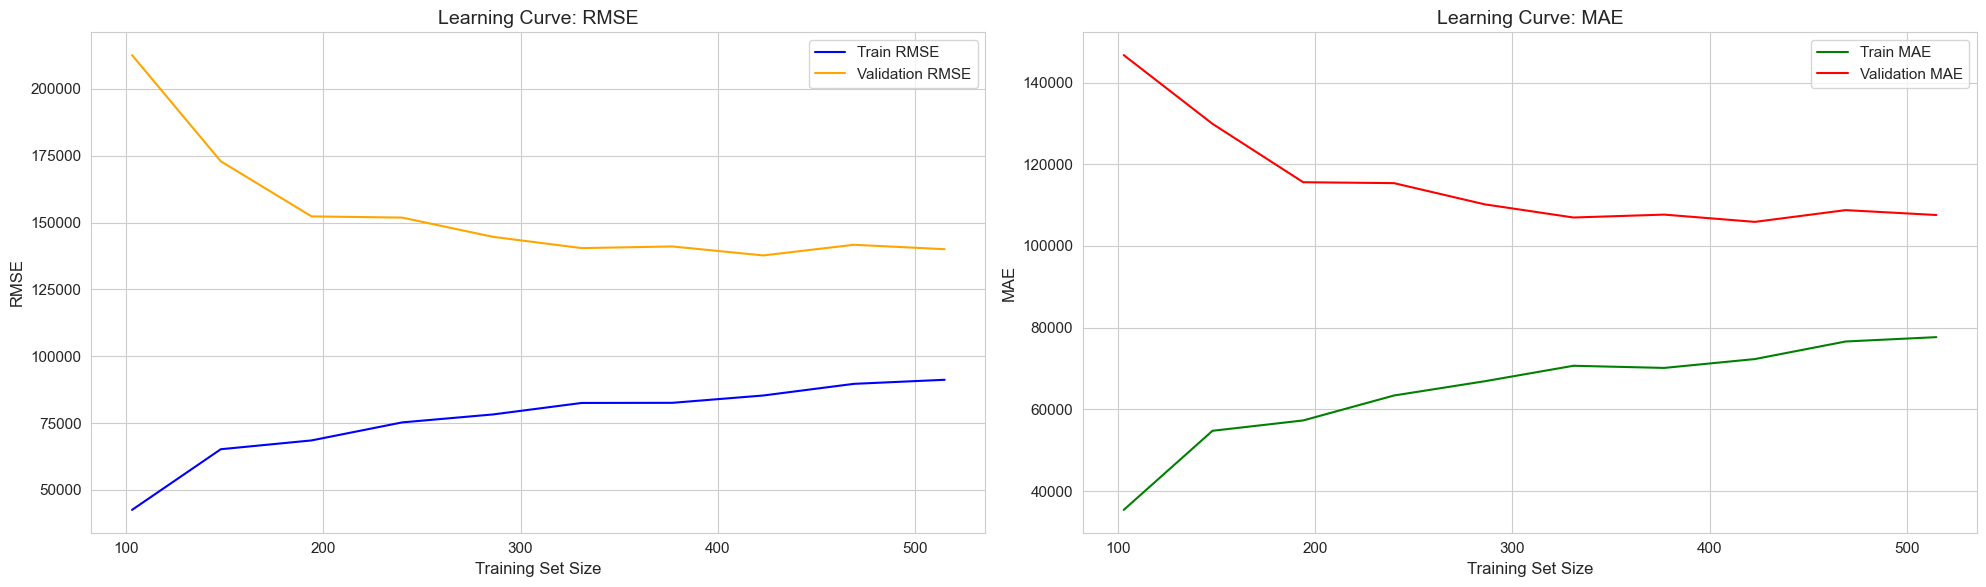

Final Training RMSE: 102,121.46
Final Test RMSE:     171,177.81
Final Training MAE:  83,590.66
Final Test MAE:      113,234.92


In [5]:
# =============================================================================
# 24 · Learning Curves (MAE & RMSE)
# =============================================================================

from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Generate learning curve data using TimeSeriesSplit
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train,
    y_train,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.2, 1.0, 10),
    n_jobs=-1
)

# Convert negative RMSE to positive
train_rmse_scores = -train_scores.mean(axis=1)
val_rmse_scores   = -val_scores.mean(axis=1)

# Also compute MAE learning curve
_, train_mae_sc, val_mae_sc = learning_curve(
    model,
    X_train,
    y_train,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.2, 1.0, 10),
    n_jobs=-1
)

train_mae_scores = -train_mae_sc.mean(axis=1)
val_mae_scores   = -val_mae_sc.mean(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plot RMSE
ax[0].plot(train_sizes, train_rmse_scores, label='Train RMSE', color='blue')
ax[0].plot(train_sizes, val_rmse_scores,   label='Validation RMSE', color='orange')
ax[0].set_title('Learning Curve: RMSE')
ax[0].set_xlabel('Training Set Size')
ax[0].set_ylabel('RMSE')
ax[0].legend()
ax[0].grid(True)

# Plot MAE
ax[1].plot(train_sizes, train_mae_scores, label='Train MAE', color='green')
ax[1].plot(train_sizes, val_mae_scores,   label='Validation MAE', color='red')
ax[1].set_title('Learning Curve: MAE')
ax[1].set_xlabel('Training Set Size')
ax[1].set_ylabel('MAE')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Print final training / test metrics (already computed above)
print(f'Final Training RMSE: {train_rmse:,.2f}')
print(f'Final Test RMSE:     {test_rmse:,.2f}')
print(f'Final Training MAE:  {train_mae:,.2f}')
print(f'Final Test MAE:      {test_mae:,.2f}')


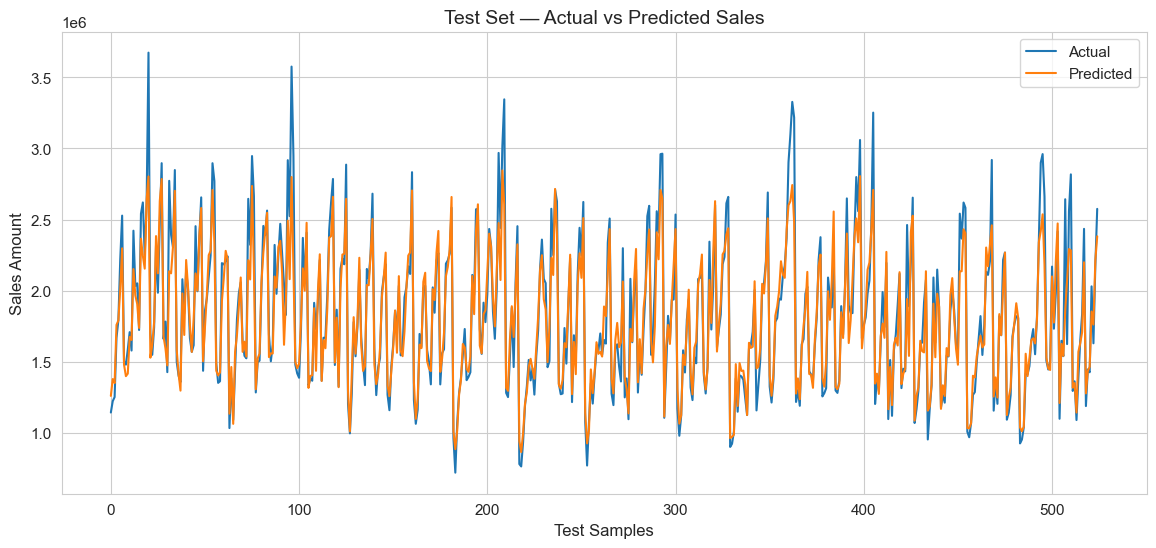

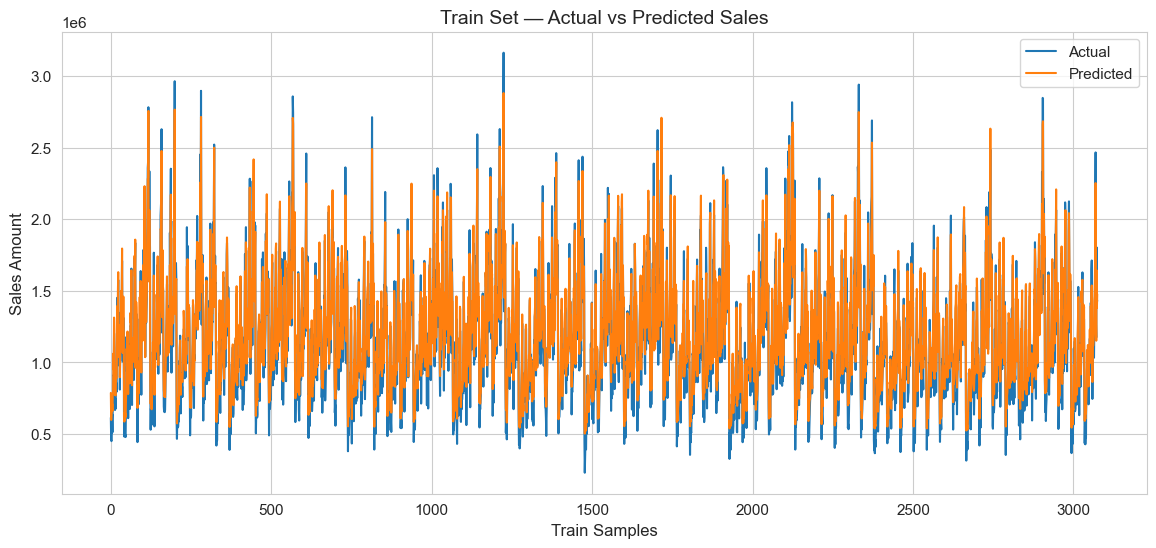

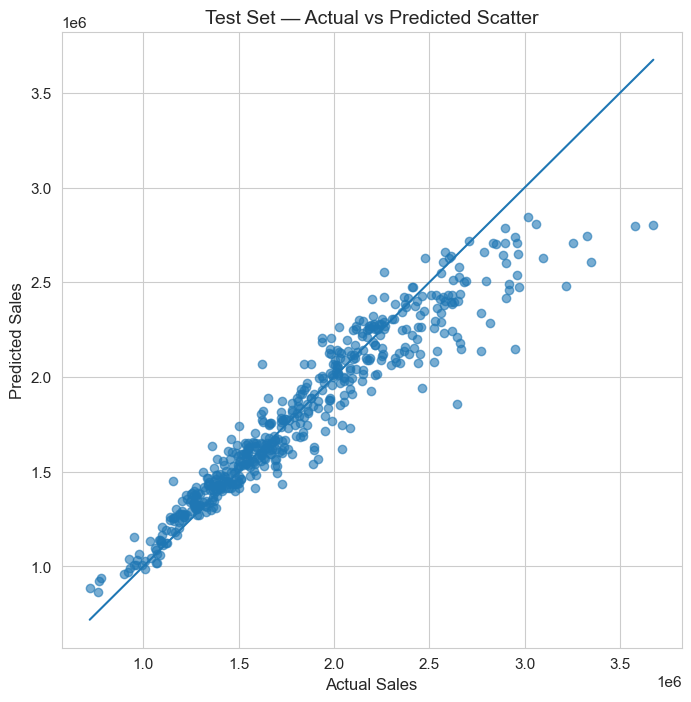

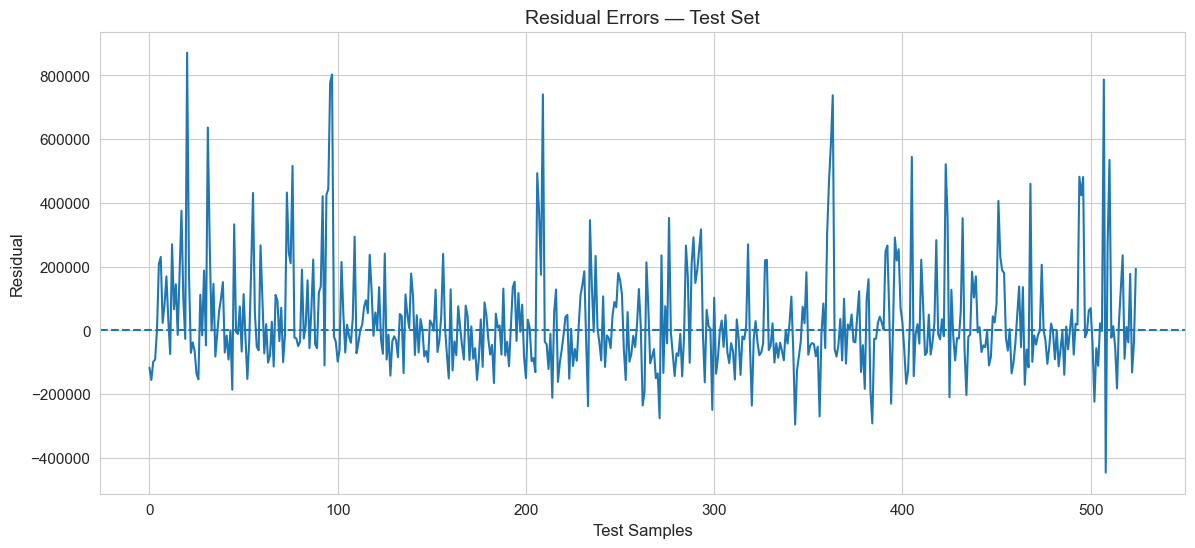

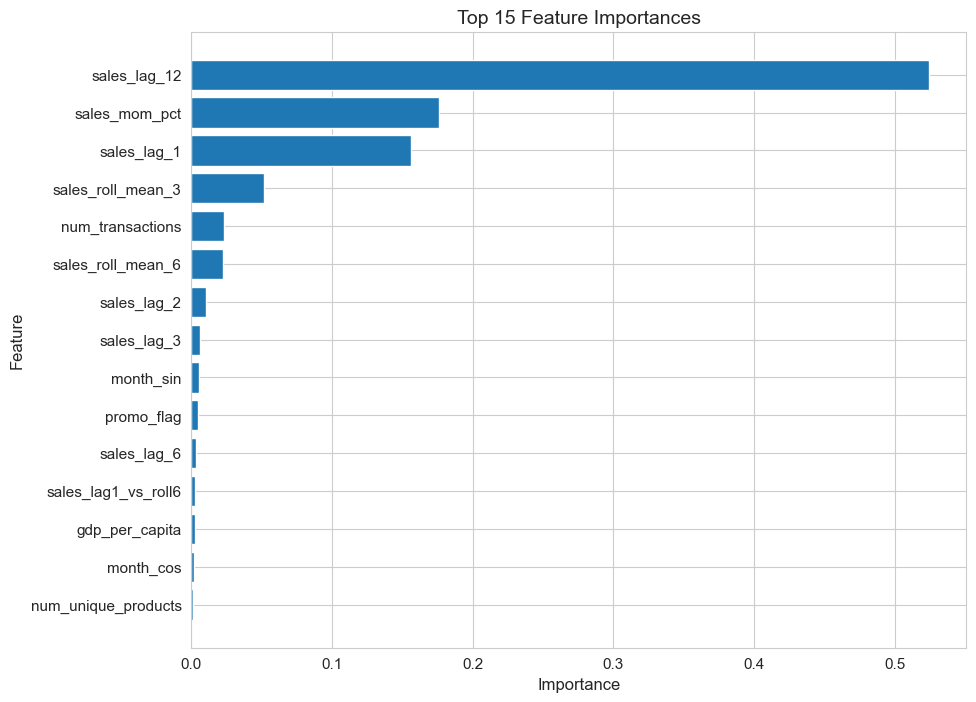

In [6]:
# =============================================================================
# PLOTS — TRAIN VS TEST PREDICTIONS
# =============================================================================

import matplotlib.pyplot as plt

# =============================================================================
# 1. ACTUAL VS PREDICTED (TEST)
# =============================================================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    test_preds,
    label='Predicted'
)

plt.title('Test Set — Actual vs Predicted Sales')

plt.xlabel('Test Samples')

plt.ylabel('Sales Amount')

plt.legend()

plt.grid(True)

plt.show()

# =============================================================================
# 2. ACTUAL VS PREDICTED (TRAIN)
# =============================================================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_train.values,
    label='Actual'
)

plt.plot(
    train_preds,
    label='Predicted'
)

plt.title('Train Set — Actual vs Predicted Sales')

plt.xlabel('Train Samples')

plt.ylabel('Sales Amount')

plt.legend()

plt.grid(True)

plt.show()

# =============================================================================
# 3. SCATTER PLOT — TEST
# =============================================================================

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    test_preds,
    alpha=0.6
)

# perfect prediction line
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.title('Test Set — Actual vs Predicted Scatter')

plt.xlabel('Actual Sales')

plt.ylabel('Predicted Sales')

plt.grid(True)

plt.show()

# =============================================================================
# 4. RESIDUALS PLOT
# =============================================================================

residuals = y_test - test_preds

plt.figure(figsize=(14, 6))

plt.plot(residuals.values)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Residual Errors — Test Set')

plt.xlabel('Test Samples')

plt.ylabel('Residual')

plt.grid(True)

plt.show()

# =============================================================================
# 5. FEATURE IMPORTANCE PLOT
# =============================================================================

top_n = 15

top_features = (
    importance_df
    .head(top_n)
    .sort_values('importance')
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.title(f'Top {top_n} Feature Importances')

plt.xlabel('Importance')

plt.ylabel('Feature')

plt.grid(True)

plt.show()

In [7]:
# =============================================================================
# FUTURE FORECASTING
# =============================================================================

future_months = 12

future_forecasts = []

# last historical data
latest_data = df_clean.copy()

# last date in dataset
last_date = latest_data['date'].max()

stores = latest_data['store_id'].unique()

# =============================================================================
# FORECAST LOOP
# =============================================================================

for step in range(1, future_months + 1):

    future_date = last_date + pd.DateOffset(months=step)

    future_rows = []

    for store in stores:

        store_hist = (
            latest_data[latest_data['store_id'] == store]
            .sort_values('date')
        )

        # need enough history
        if len(store_hist) < 12:
            continue

        row = {}

        # ---------------------------------------------------------
        # identifiers
        # ---------------------------------------------------------

        row['store_id'] = store
        row['date'] = future_date

        row['year'] = future_date.year
        row['month'] = future_date.month

        # ---------------------------------------------------------
        # lag features
        # ---------------------------------------------------------

        recent_sales = (
            store_hist[TARGET]
            .tail(12)
            .tolist()
        )

        row['sales_lag_1']  = recent_sales[-1]
        row['sales_lag_2']  = recent_sales[-2]
        row['sales_lag_3']  = recent_sales[-3]
        row['sales_lag_6']  = recent_sales[-6]
        row['sales_lag_12'] = recent_sales[-12]

        # ---------------------------------------------------------
        # rolling features
        # ---------------------------------------------------------

        row['sales_roll_mean_3'] = np.mean(recent_sales[-3:])
        row['sales_roll_mean_6'] = np.mean(recent_sales[-6:])

        # ---------------------------------------------------------
        # momentum
        # ---------------------------------------------------------

        if recent_sales[-2] != 0:

            row['sales_mom_pct'] = (
                (recent_sales[-1] - recent_sales[-2])
                / recent_sales[-2]
            )

        else:
            row['sales_mom_pct'] = 0

        row['sales_lag1_vs_roll6'] = (
            row['sales_lag_1'] /
            max(row['sales_roll_mean_6'], 1)
        )

        # ---------------------------------------------------------
        # pricing / business features
        # ---------------------------------------------------------

        row['price_realistic'] = (
            store_hist['price_realistic']
            .iloc[-1]
        )

        row['promo_flag'] = (
            store_hist['promo_flag']
            .iloc[-1]
        )

        row['num_transactions'] = (
            store_hist['num_transactions']
            .iloc[-1]
        )

        row['num_unique_products'] = (
            store_hist['num_unique_products']
            .iloc[-1]
        )

        row['num_categories'] = (
            store_hist['num_categories']
            .iloc[-1]
        )

        # ---------------------------------------------------------
        # cyclical features
        # ---------------------------------------------------------

        row['month_sin'] = np.sin(
            2 * np.pi * row['month'] / 12
        )

        row['month_cos'] = np.cos(
            2 * np.pi * row['month'] / 12
        )

        row['is_holiday_season'] = int(
            row['month'] in [11, 12]
        )

        row['is_launch_season'] = int(
            row['month'] in [9, 10]
        )

        # ---------------------------------------------------------
        # economics
        # ---------------------------------------------------------

        for col in [

            'gdp_per_capita',
            'inflation_rate',
            'exchange_rate',
            'internet_usage_pct',

            'gdp_change',
            'inflation_change',
            'exchange_change',
            'internet_usage_change'
        ]:

            if col in store_hist.columns:

                row[col] = (
                    store_hist[col]
                    .iloc[-1]
                )

        # ---------------------------------------------------------
        # encoding
        # ---------------------------------------------------------

        row['store_encoded'] = (
            store_hist['store_encoded']
            .iloc[-1]
        )

        # ---------------------------------------------------------
        # dataframe
        # ---------------------------------------------------------

        row_df = pd.DataFrame([row])

        # align columns
        row_df = row_df.reindex(
            columns=FEATURES,
            fill_value=0
        )

        # ---------------------------------------------------------
        # predict
        # ---------------------------------------------------------

        pred = model.predict(row_df)[0]

        # avoid negatives
        pred = max(pred, 0)

        row[TARGET] = pred

        future_rows.append(row)

    # -------------------------------------------------------------
    # append month predictions
    # -------------------------------------------------------------

    future_month_df = pd.DataFrame(future_rows)

    future_forecasts.append(future_month_df)

    latest_data = pd.concat(
        [latest_data, future_month_df],
        ignore_index=True
    )

# =============================================================================
# FINAL FORECAST DATAFRAME
# =============================================================================

future_forecasts_df = pd.concat(
    future_forecasts,
    ignore_index=True
)

print()
print('=' * 60)
print('FUTURE FORECASTS')
print('=' * 60)

print(future_forecasts_df[
    ['store_id', 'date', TARGET]
].head(20))

# =============================================================================
# SAVE FORECASTS
# =============================================================================

future_forecasts_df.to_csv(
    'future_sales_forecasts.csv',
    index=False
)

print()
print('✅ Future forecasts saved')


FUTURE FORECASTS
   store_id       date  sales_amount_realistic
0      ST-1 2026-01-01            1.709596e+06
1     ST-10 2026-01-01            1.429211e+06
2     ST-11 2026-01-01            2.763259e+06
3     ST-12 2026-01-01            2.031219e+06
4     ST-13 2026-01-01            2.151006e+06
5     ST-14 2026-01-01            1.577476e+06
6     ST-15 2026-01-01            2.327631e+06
7     ST-16 2026-01-01            2.087692e+06
8     ST-17 2026-01-01            1.658179e+06
9     ST-18 2026-01-01            1.912894e+06
10    ST-19 2026-01-01            1.907270e+06
11     ST-2 2026-01-01            1.960624e+06
12    ST-20 2026-01-01            1.942653e+06
13    ST-21 2026-01-01            1.983822e+06
14    ST-22 2026-01-01            1.787017e+06
15    ST-23 2026-01-01            1.768134e+06
16    ST-24 2026-01-01            2.141019e+06
17    ST-25 2026-01-01            2.264924e+06
18    ST-26 2026-01-01            1.906837e+06
19    ST-27 2026-01-01            2.301160

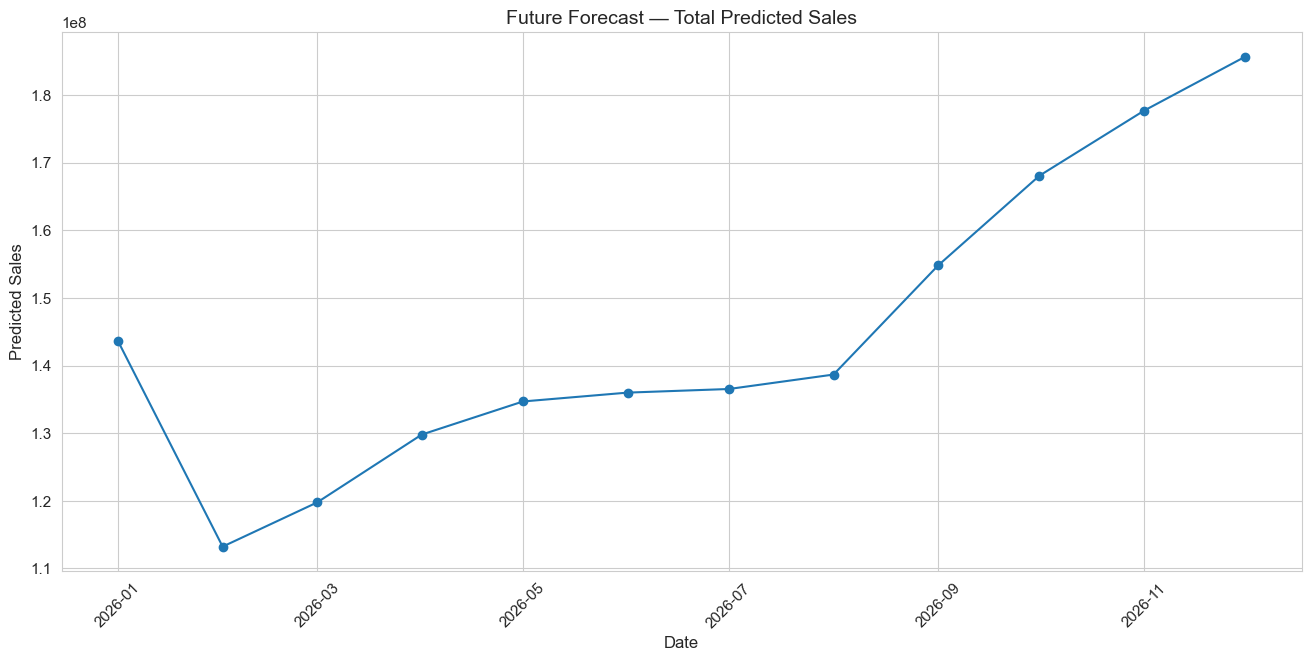

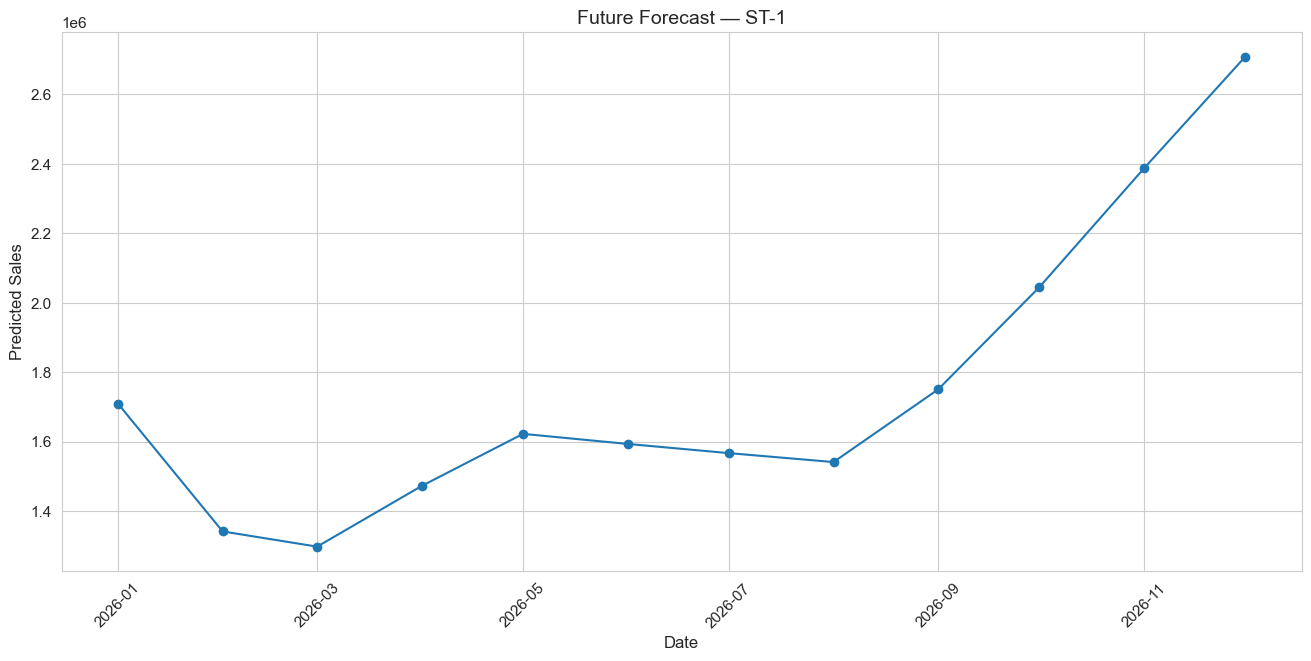

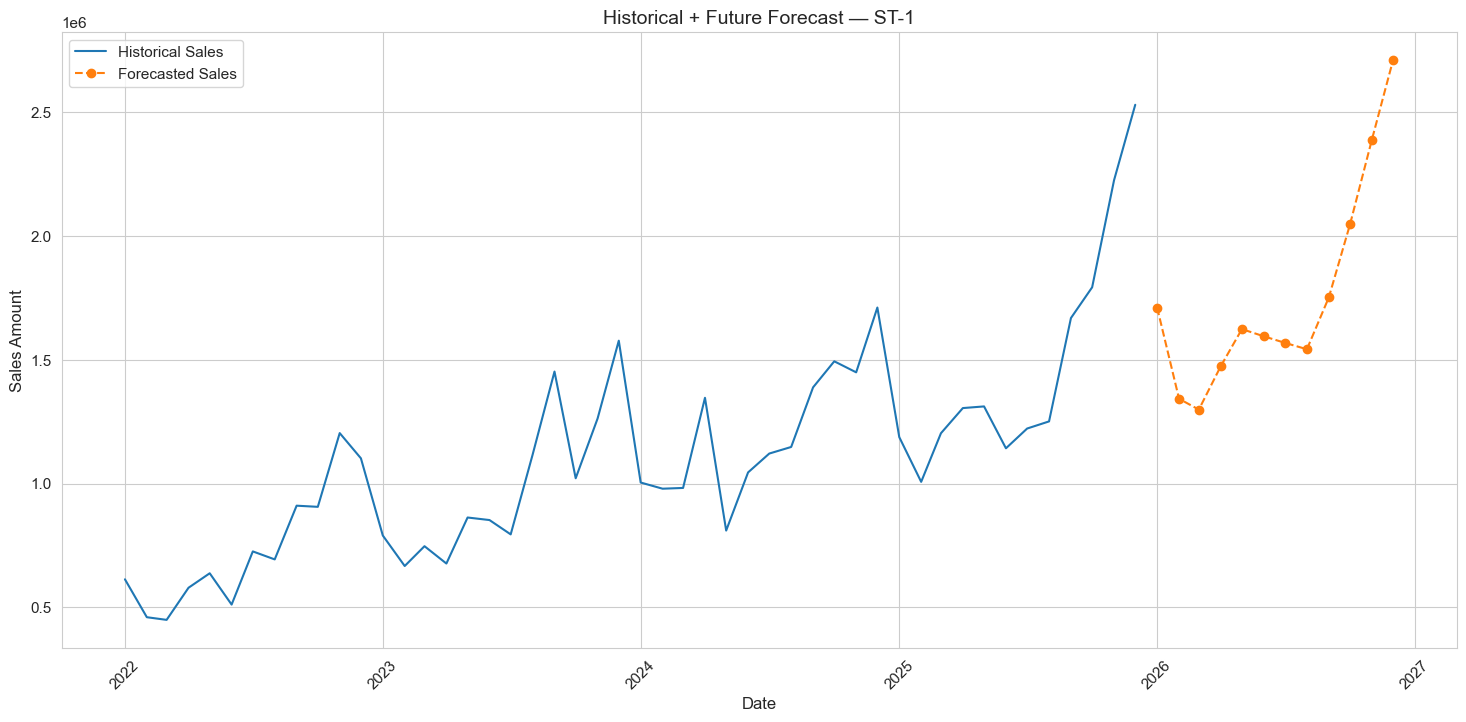

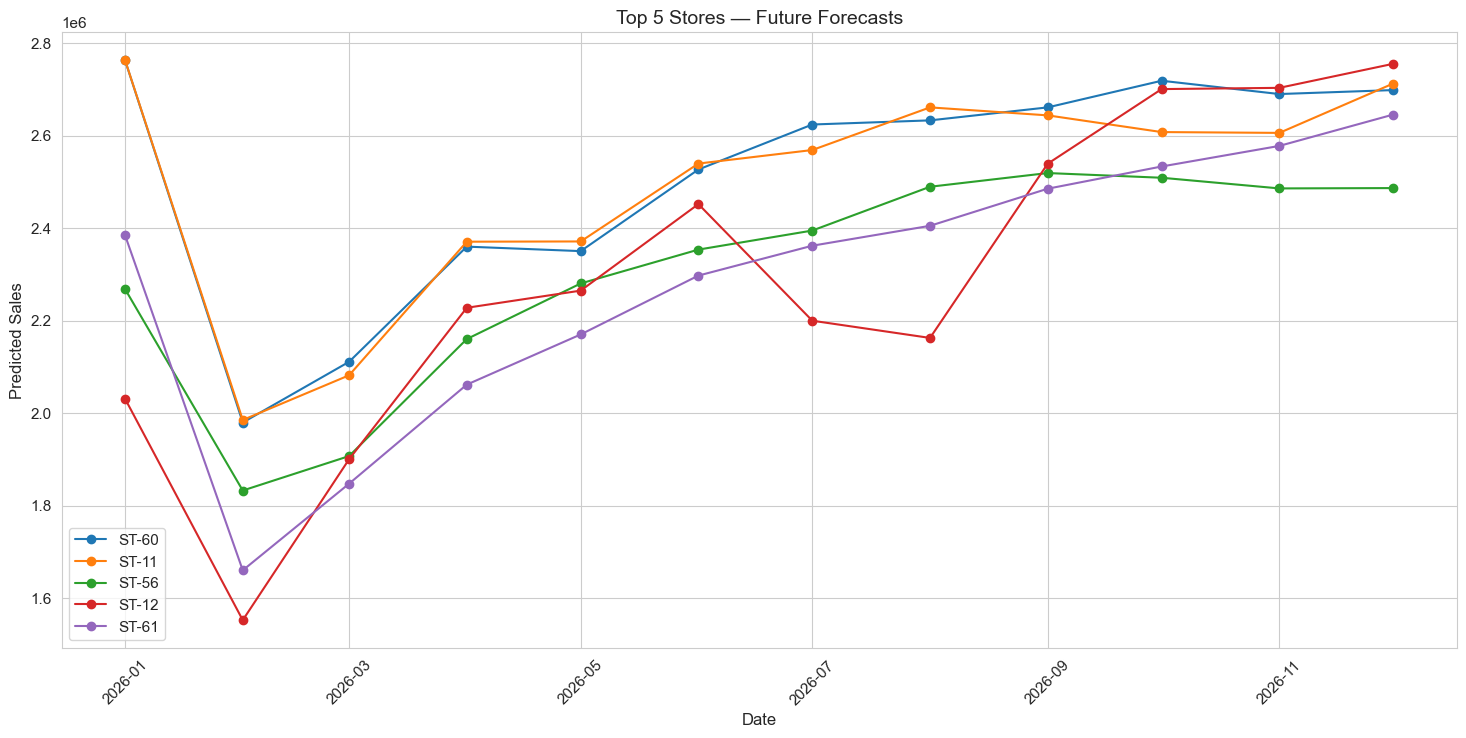

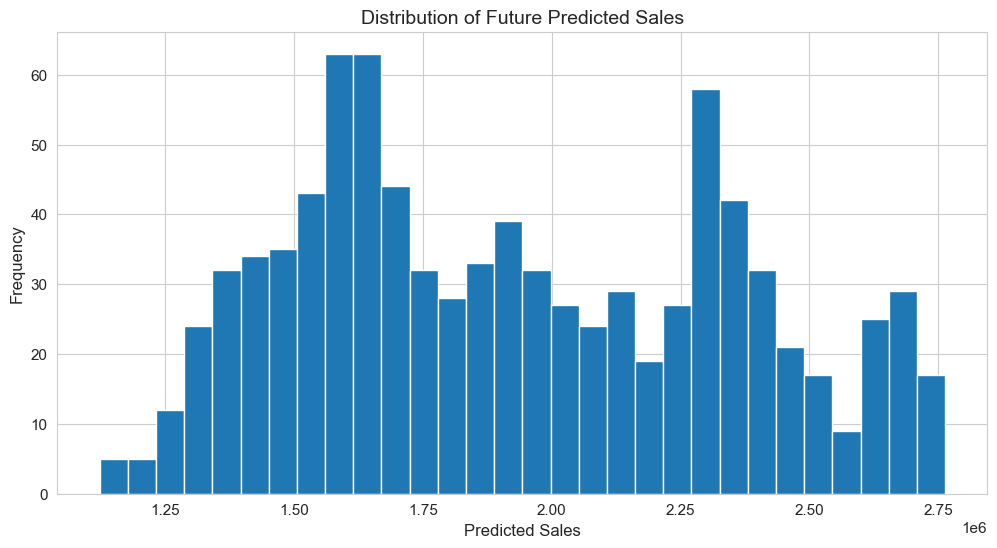

In [8]:
# =============================================================================
# FUTURE FORECAST PLOTS
# =============================================================================

import matplotlib.pyplot as plt

# =============================================================================
# 1. OVERALL FUTURE FORECAST
# =============================================================================

plt.figure(figsize=(16, 7))

# total sales per month
monthly_future = (
    future_forecasts_df
    .groupby('date')[TARGET]
    .sum()
    .reset_index()
)

plt.plot(
    monthly_future['date'],
    monthly_future[TARGET],
    marker='o'
)

plt.title('Future Forecast — Total Predicted Sales')

plt.xlabel('Date')

plt.ylabel('Predicted Sales')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# =============================================================================
# 2. SINGLE STORE FORECAST
# =============================================================================

# choose store
selected_store = 'ST-1'

store_future = (
    future_forecasts_df[
        future_forecasts_df['store_id'] == selected_store
    ]
)

plt.figure(figsize=(16, 7))

plt.plot(
    store_future['date'],
    store_future[TARGET],
    marker='o'
)

plt.title(f'Future Forecast — {selected_store}')

plt.xlabel('Date')

plt.ylabel('Predicted Sales')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

# =============================================================================
# 3. HISTORY + FUTURE COMBINED
# =============================================================================

# historical data
store_history = (
    df_clean[
        df_clean['store_id'] == selected_store
    ]
    .sort_values('date')
)

plt.figure(figsize=(18, 8))

# historical
plt.plot(
    store_history['date'],
    store_history[TARGET],
    label='Historical Sales'
)

# future
plt.plot(
    store_future['date'],
    store_future[TARGET],
    marker='o',
    linestyle='--',
    label='Forecasted Sales'
)

plt.title(f'Historical + Future Forecast — {selected_store}')

plt.xlabel('Date')

plt.ylabel('Sales Amount')

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

# =============================================================================
# 4. TOP STORES FORECAST
# =============================================================================

top_stores = (
    future_forecasts_df
    .groupby('store_id')[TARGET]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(18, 8))

for store in top_stores:

    temp = (
        future_forecasts_df[
            future_forecasts_df['store_id'] == store
        ]
    )

    plt.plot(
        temp['date'],
        temp[TARGET],
        marker='o',
        label=store
    )

plt.title('Top 5 Stores — Future Forecasts')

plt.xlabel('Date')

plt.ylabel('Predicted Sales')

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

# =============================================================================
# 5. FUTURE DISTRIBUTION
# =============================================================================

plt.figure(figsize=(12, 6))

plt.hist(
    future_forecasts_df[TARGET],
    bins=30
)

plt.title('Distribution of Future Predicted Sales')

plt.xlabel('Predicted Sales')

plt.ylabel('Frequency')

plt.grid(True)

plt.show()

In [9]:
# =============================================================================
# GENERALIZATION SCORE
# =============================================================================

# Better overfitting indicator

r2_gap_pct = ((train_r2 - test_r2) / train_r2) * 100

print(f'R² Generalization Loss: {r2_gap_pct:.2f}%')

if r2_gap_pct < 5:
    print("✅ Very Healthy Model")

elif r2_gap_pct < 10:
    print("✅ Acceptable Overfitting")

elif r2_gap_pct < 20:
    print("⚠ Moderate Overfitting")

else:
    print("❌ Severe Overfitting")

R² Generalization Loss: 5.16%
✅ Acceptable Overfitting


In [10]:
# Average actual sales
avg_sales = y_test.mean()

# Error percentage using RMSE
rmse_pct = (test_rmse / avg_sales) * 100

# Error percentage using MAE
mae_pct = (test_mae / avg_sales) * 100

print('=' * 60)

print(f'Average Sales : {avg_sales:,.2f}')

print()

print(f'RMSE % : {rmse_pct:.2f}%')
print(f'MAE  % : {mae_pct:.2f}%')

print('=' * 60)

Average Sales : 1,822,245.77

RMSE % : 9.39%
MAE  % : 6.21%
